# Dataset Analysis for Numericals Datasets

## Libraries


In [4]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [5]:
%store -r data
data=data

%store -r numerical_cols
numerical_cols=numerical_cols



##  Descriptive Analysis

#### Numerical Data

In [ ]:
numerical_cols= data.select_dtypes(include=['int64','float64' ]).columns.tolist()
print(data[numerical_cols].columns)
print(data[numerical_cols])

Index(['year of manufacture', 'Engine power (kilowatt)', 'Cubic capacity',
       ' Number of gears', 'CO2 (g/km)', 'Mileage', 'Empty weight (kg)',
       'Permitted gross weight', 'Acceleration (0-100Km/h)', 'max_speed_kmh',
       'Nber of gears', 'Nber of seats', 'Nber previous owners',
       'Number of doors', 'damaged_front', 'damaged_rear', 'damaged_link_side',
       'damaged_interior', 'damaged_exterior', 'accessory_missing',
       'damaged_tire', 'damaged_rim', 'damaged_roof_beam', 'damaged_mirror',
       'damaged_link_door', 'damaged_right_door', 'Nber_of_key',
       'missing_winter_tires', 'major_inspection_due', 'comfort_features',
       'navigation_sytem', 'safety_features', 'leasing_car', 'damaged_repair',
       'has_winter_package', 'has_seat_heating_front', 'has_metallic_paint',
       'space_saver_spare_wheel', 'has_headlight_washer',
       'has_foldable_front_passenger_seat', 'has_warning_light',
       'license_plate_holder', 'luggage_compartment_safety_net',


In [ ]:
def kde_plot(x):
    col = x[0]

    plt.figure(figsize=(12,6))

    # Histogramm
    sns.histplot(data[x[0]], kde=False, alpha=0.25)

    # KDE-Plot
    sns.kdeplot(data[x[0]], linewidth=5)
    
    # Calculate mean and median
    mean=data[col].mean()
    median=data[col].median()
    
    # Add mean and median lines
    plt.axvline(mean, color='r', linestyle='--', label=f'Mean: {mean:.2f}')
    plt.axvline(median, color='g', linestyle='-', label=f'Median: {median:.2f}')
    
    # Add legend and labels
    plt.legend()
    plt.title(f'KDE Plot of {col}')
    plt.xlabel(x)
    plt.ylabel('Density')

    return plt.show()



In [3]:
# Generate KDE plots for all numerical columns
# for col in numerical_cols:
#     kde_plot([col])

#     print('\n\n')

#### Scatter Plot

In [ ]:
def scatter_plot(x):
    col=x[0]

    plt.figure(figsize=(12,6))

    # Scatter plot with regression line 
    sns.scatterplot(x=data[col], y=data['Sale price'], alpha=0.5, color='red')
    sns.regplot(x=data[col], y=data['Sale price'], scatter=False, color='black', line_kws={"linewidth":3})
    # Add labels and title 
    plt.title(f'Scatter Plot of {col} vs Sale Price')
    plt.xlabel(col)
    plt.ylabel('Price (EUR)')

    return plt.show()

In [2]:
# for col in numerical_cols:
#     scatter_plot([col])

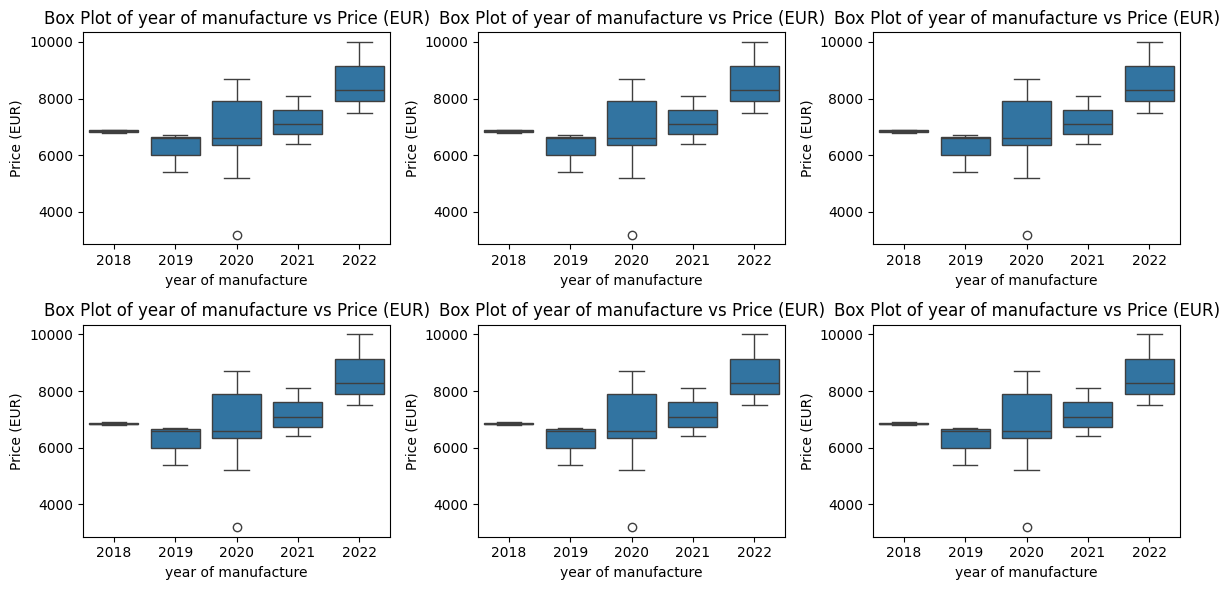

In [ ]:
def box_plot(x):
    col=x[0]
    
    fig, axes = plt.subplots(nrows=2, ncols=3,figsize=(12,6))

    for i, ax in enumerate(axes.flatten()):
        sns.boxplot(x=data[col], y=data['Sale price'], ax=ax)
        ax.set_title(f'Box Plot of {col} vs Price (EUR)')
        ax.set_xlabel(col)
        ax.set_ylabel('Price (EUR)')

    plt.tight_layout()
    return plt.show()
        
box_plot(numerical_cols)


#### Correlation Variables
Analyse relation between variables.

Domain: -1 to 1

. 1 -> perfect positive correlation
. -1 -> perfect negative correlation
. 0 -> no correlation


| r (Korrelationskoeffizient) | Stärke des Zusammenhangs |
| --------------------------- | ------------------------ |
| 0.00 – 0.19                 | sehr schwach             |
| 0.20 – 0.39                 | schwach                  |
| 0.40 – 0.59                 | mittel                   |
| 0.60 – 0.79                 | stark                    |
| 0.80 – 1.0                  | sehr stark               |


In [ ]:
pearson_corr = data[numerical_cols].corr(method='pearson')
plt.figure(figsize=(100, 90))
sns.heatmap(pearson_corr,
             annot=True,
             vmax=1,
             vmin=-1,
             fmt=".2f", 
             cmap='coolwarm', 
             center=0,
            annot_kws={"size": 23} )
plt.title('Pearson Correlation Heatmap')
plt.xticks(fontsize=20)  
plt.yticks(fontsize=20)
plt.show()

VIF (Variance Inflation Factor) misst, wie stark die Varianz eines Regressionskoeffizienten durch die Korrelation mit anderen unabhängigen Variablen „aufgeblasen“ wird.

Einfach gesagt: VIF sagt dir, wie stark ein Feature redundant mit anderen Features ist.

Hohe VIF-Werte → Multikollinearität → Modell instabil

In [ ]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

def multi_collinearity_analysis(data):

    # Annahme: numerische Features (ohne Zielvariable)
    numerical_cols = data.select_dtypes(include='number').columns.tolist()
    target = 'Sale price'
    X = data[numerical_cols].drop(target, axis=1).fillna(0)  # unabhängige Variablen

    # 1️. Stark korrelierte Paare erkennen (r > 0.7)
    corr_matrix = X.corr().abs()
    high_corr_pairs = []

    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if corr_matrix.iloc[i,j] > 0.7:
                high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i,j]))

    print("Stark korrelierte Feature-Paare (r > 0.7):")
    for pair in high_corr_pairs:
        print(f"{pair[0]} ↔ {pair[1]} = {pair[2]:.2f}")

    # 2️⃣ VIF berechnen
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    print("\nVariance Inflation Factor (VIF) für jedes Feature:")
    print(vif_data)


In [ ]:
multi_collinearity_analysis(data)

Stark korrelierte Feature-Paare (r > 0.7):
year of manufacture ↔ Cubic capacity = 0.75
Engine power (kilowatt) ↔ Nber of seats = 0.73
Cubic capacity ↔  Number of gears = 0.82
Cubic capacity ↔ CO2 (g/km) = 0.85
Cubic capacity ↔ has_seat_heating_front = 0.72
Permitted gross weight ↔ Nber of seats = 0.73
Permitted gross weight ↔ has_metallic_paint = 0.71
Acceleration (0-100Km/h) ↔ has_winter_package = 0.74
Nber of seats ↔ Number of doors = 0.76
Nber of seats ↔ has_metallic_paint = 0.76
damaged_front ↔ damaged_interior = 0.76
damaged_tire ↔ damaged_rim = 0.74

Variance Inflation Factor (VIF) für jedes Feature:
                                 Feature  VIF
0                    year of manufacture  inf
1                Engine power (kilowatt)  inf
2                         Cubic capacity  inf
3                        Number of gears  inf
4                             CO2 (g/km)  inf
5                                Mileage  inf
6                      Empty weight (kg)  inf
7                 

In [ ]:
print(data.columns.tolist())


['Brand ', 'Model', 'year of manufacture', 'Engine power (kilowatt)', 'Transmission type', 'Emission group', 'Cubic capacity', ' Number of gears', 'CO2 (g/km)', 'Date of general inspection', 'Mileage', 'Empty weight (kg)', 'Permitted gross weight', 'Acceleration (0-100Km/h)', 'max_speed_kmh', 'Region', 'Engine type', 'next general inspection', 'Color', 'Vehicle model', 'Nber of gears', 'Nber of seats', 'Nber previous owners', 'Number of doors', 'First_registration _car', 'Ready to drive', 'Body style', 'Tire type', 'Rim type', 'Rights of third parties', 'Transmission type2', 'Accident history', 'damaged_front', 'damaged_rear', 'damaged_link_side', 'damaged_interior', 'damaged_exterior', 'accessory_missing', 'damaged_tire', 'damaged_rim', 'damaged_roof_beam', 'damaged_mirror', 'damaged_link_door', 'damaged_right_door', 'Nber_of_key', 'missing_winter_tires', 'major_inspection_due', 'comfort_features', 'navigation_sytem', 'safety_features', 'leasing_car', 'damaged_repair', 'has_winter_pac

In [ ]:
# Liste der zu löschenden Spalten
cols_to_drop = ['Engine power (Horsepower)', 'Tank capacity', 'has_foldable_seat_tables','damaged_right_side','CO2 (g/km)','Cubic capacity']

# Nur Spalten löschen, die tatsächlich im DataFrame existieren
cols_to_drop_existing = [col for col in cols_to_drop if col in data.columns]

# Löschen
data = data.drop(columns=cols_to_drop_existing)

# Nur numerische Spalten, die aktuell im DataFrame existieren
numerical_cols = [col for col in numerical_cols if col in data.columns]


In [ ]:
multi_collinearity_analysis(data)

Stark korrelierte Feature-Paare (r > 0.7):
Engine power (kilowatt) ↔ Nber of seats = 0.73
Permitted gross weight ↔ Nber of seats = 0.73
Permitted gross weight ↔ has_metallic_paint = 0.71
Acceleration (0-100Km/h) ↔ has_winter_package = 0.74
Nber of seats ↔ Number of doors = 0.76
Nber of seats ↔ has_metallic_paint = 0.76
damaged_front ↔ damaged_interior = 0.76
damaged_tire ↔ damaged_rim = 0.74

Variance Inflation Factor (VIF) für jedes Feature:
                                 Feature  VIF
0                    year of manufacture  inf
1                Engine power (kilowatt)  inf
2                        Number of gears  inf
3                                Mileage  inf
4                      Empty weight (kg)  inf
5                 Permitted gross weight  inf
6               Acceleration (0-100Km/h)  inf
7                          max_speed_kmh  inf
8                          Nber of gears  inf
9                          Nber of seats  inf
10                  Nber previous owners  inf
1

In [ ]:
print(data.columns.tolist())



['Brand ', 'Model', 'year of manufacture', 'Engine power (kilowatt)', 'Transmission type', 'Emission group', 'Cubic capacity', ' Number of gears', 'CO2 (g/km)', 'Date of general inspection', 'Mileage', 'Empty weight (kg)', 'Permitted gross weight', 'Acceleration (0-100Km/h)', 'max_speed_kmh', 'Region', 'Engine type', 'next general inspection', 'Color', 'Vehicle model', 'Nber of gears', 'Nber of seats', 'Nber previous owners', 'Number of doors', 'First_registration _car', 'Ready to drive', 'Body style', 'Tire type', 'Rim type', 'Rights of third parties', 'Transmission type2', 'Accident history', 'damaged_front', 'damaged_rear', 'damaged_link_side', 'damaged_interior', 'damaged_exterior', 'accessory_missing', 'damaged_tire', 'damaged_rim', 'damaged_roof_beam', 'damaged_mirror', 'damaged_link_door', 'damaged_right_door', 'Nber_of_key', 'missing_winter_tires', 'major_inspection_due', 'comfort_features', 'navigation_sytem', 'safety_features', 'leasing_car', 'damaged_repair', 'has_winter_pac

In [ ]:
%store data
%store numerical_cols

Stored 'data' (DataFrame)
Stored 'numerical_cols' (list)
